<a href="https://colab.research.google.com/github/nullux0/Tomato-Detection-Web/blob/main/%EC%B5%9C%EC%A2%85%EB%AA%A8%EB%8D%B8(YOLOv8n%2Bscale%3D0_9).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
 !pip install ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 148.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


In [2]:
from roboflow import Roboflow

rf = Roboflow(api_key="dNkkBeBkjPfg3hRZo2LD")
project = rf.workspace("s-workspace-ppqwh").project("my-first-project-egeaa")
version = project.version(2)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to My-First-Project-2 in yolov8:: 100%|██████████| 605/605 [00:00<00:00, 2521.54it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from ultralytics import YOLO

In [4]:
print(dataset.location)

/content/My-First-Project-2


In [5]:
baseline = YOLO("yolov8n.pt")
baseline.train(
    data='/content/My-First-Project-2/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name="exp_scale",
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
    fliplr=0.0, mosaic=0.0, scale=0.9,
)
m_base = baseline.val()
print("model mAP50:", m_base.box.map50, "mAP50-95:", m_base.box.map)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/My-First-Project-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=exp_scale, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

In [6]:
# ONNX 변환
!pip install -q onnx onnxruntime onnxslim

from ultralytics import YOLO
model = YOLO('/content/runs/detect/exp_scale/weights/best.pt')
model.export(format='onnx', imgsz=640)
print("✅ ONNX 변환 완료 → /content/runs/detect/exp_scale/weights/best.onnx")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 26.0 MB/s eta 0:00:00
Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/exp_scale/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (6.0 MB)

ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 1.2s, saved as '/content/runs/detect/exp_scale/weights/best.onnx' (11.7 MB)

Export complete (1.5s)
Results saved to /content/runs/detect/exp_scale/weights/best.onnx
Predict:         yo

In [7]:
from ultralytics import YOLO
import numpy as np, time, glob, cv2

img = cv2.imread(glob.glob('/content/My-First-Project-2/valid/images/*.jpg')[0])

def bench(weights, img, n=50, warmup=10):
    m = YOLO(weights)
    for _ in range(warmup):
        m.predict(img, device='cpu', imgsz=640, verbose=False)
    ts = np.array([ (lambda s: (m.predict(img, device='cpu', imgsz=640, verbose=False), (time.perf_counter()-s)*1000)[1])(time.perf_counter()) for _ in range(n) ])
    return np.median(ts), ts.mean(), ts.std()

for name, w in [("PyTorch", '/content/runs/detect/exp_scale/weights/best.pt'),
                ("ONNX",    '/content/runs/detect/exp_scale/weights/best.onnx')]:
    med, mean, std = bench(w, img)
    print(f"{name:8s} CPU : median {med:6.1f} | mean {mean:6.1f} ± {std:.1f} ms")

PyTorch  CPU : median  222.9 | mean  233.9 ± 121.6 ms
Loading /content/runs/detect/exp_scale/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.27.0 with CPUExecutionProvider
ONNX     CPU : median   93.9 | mean   99.5 ± 13.8 ms


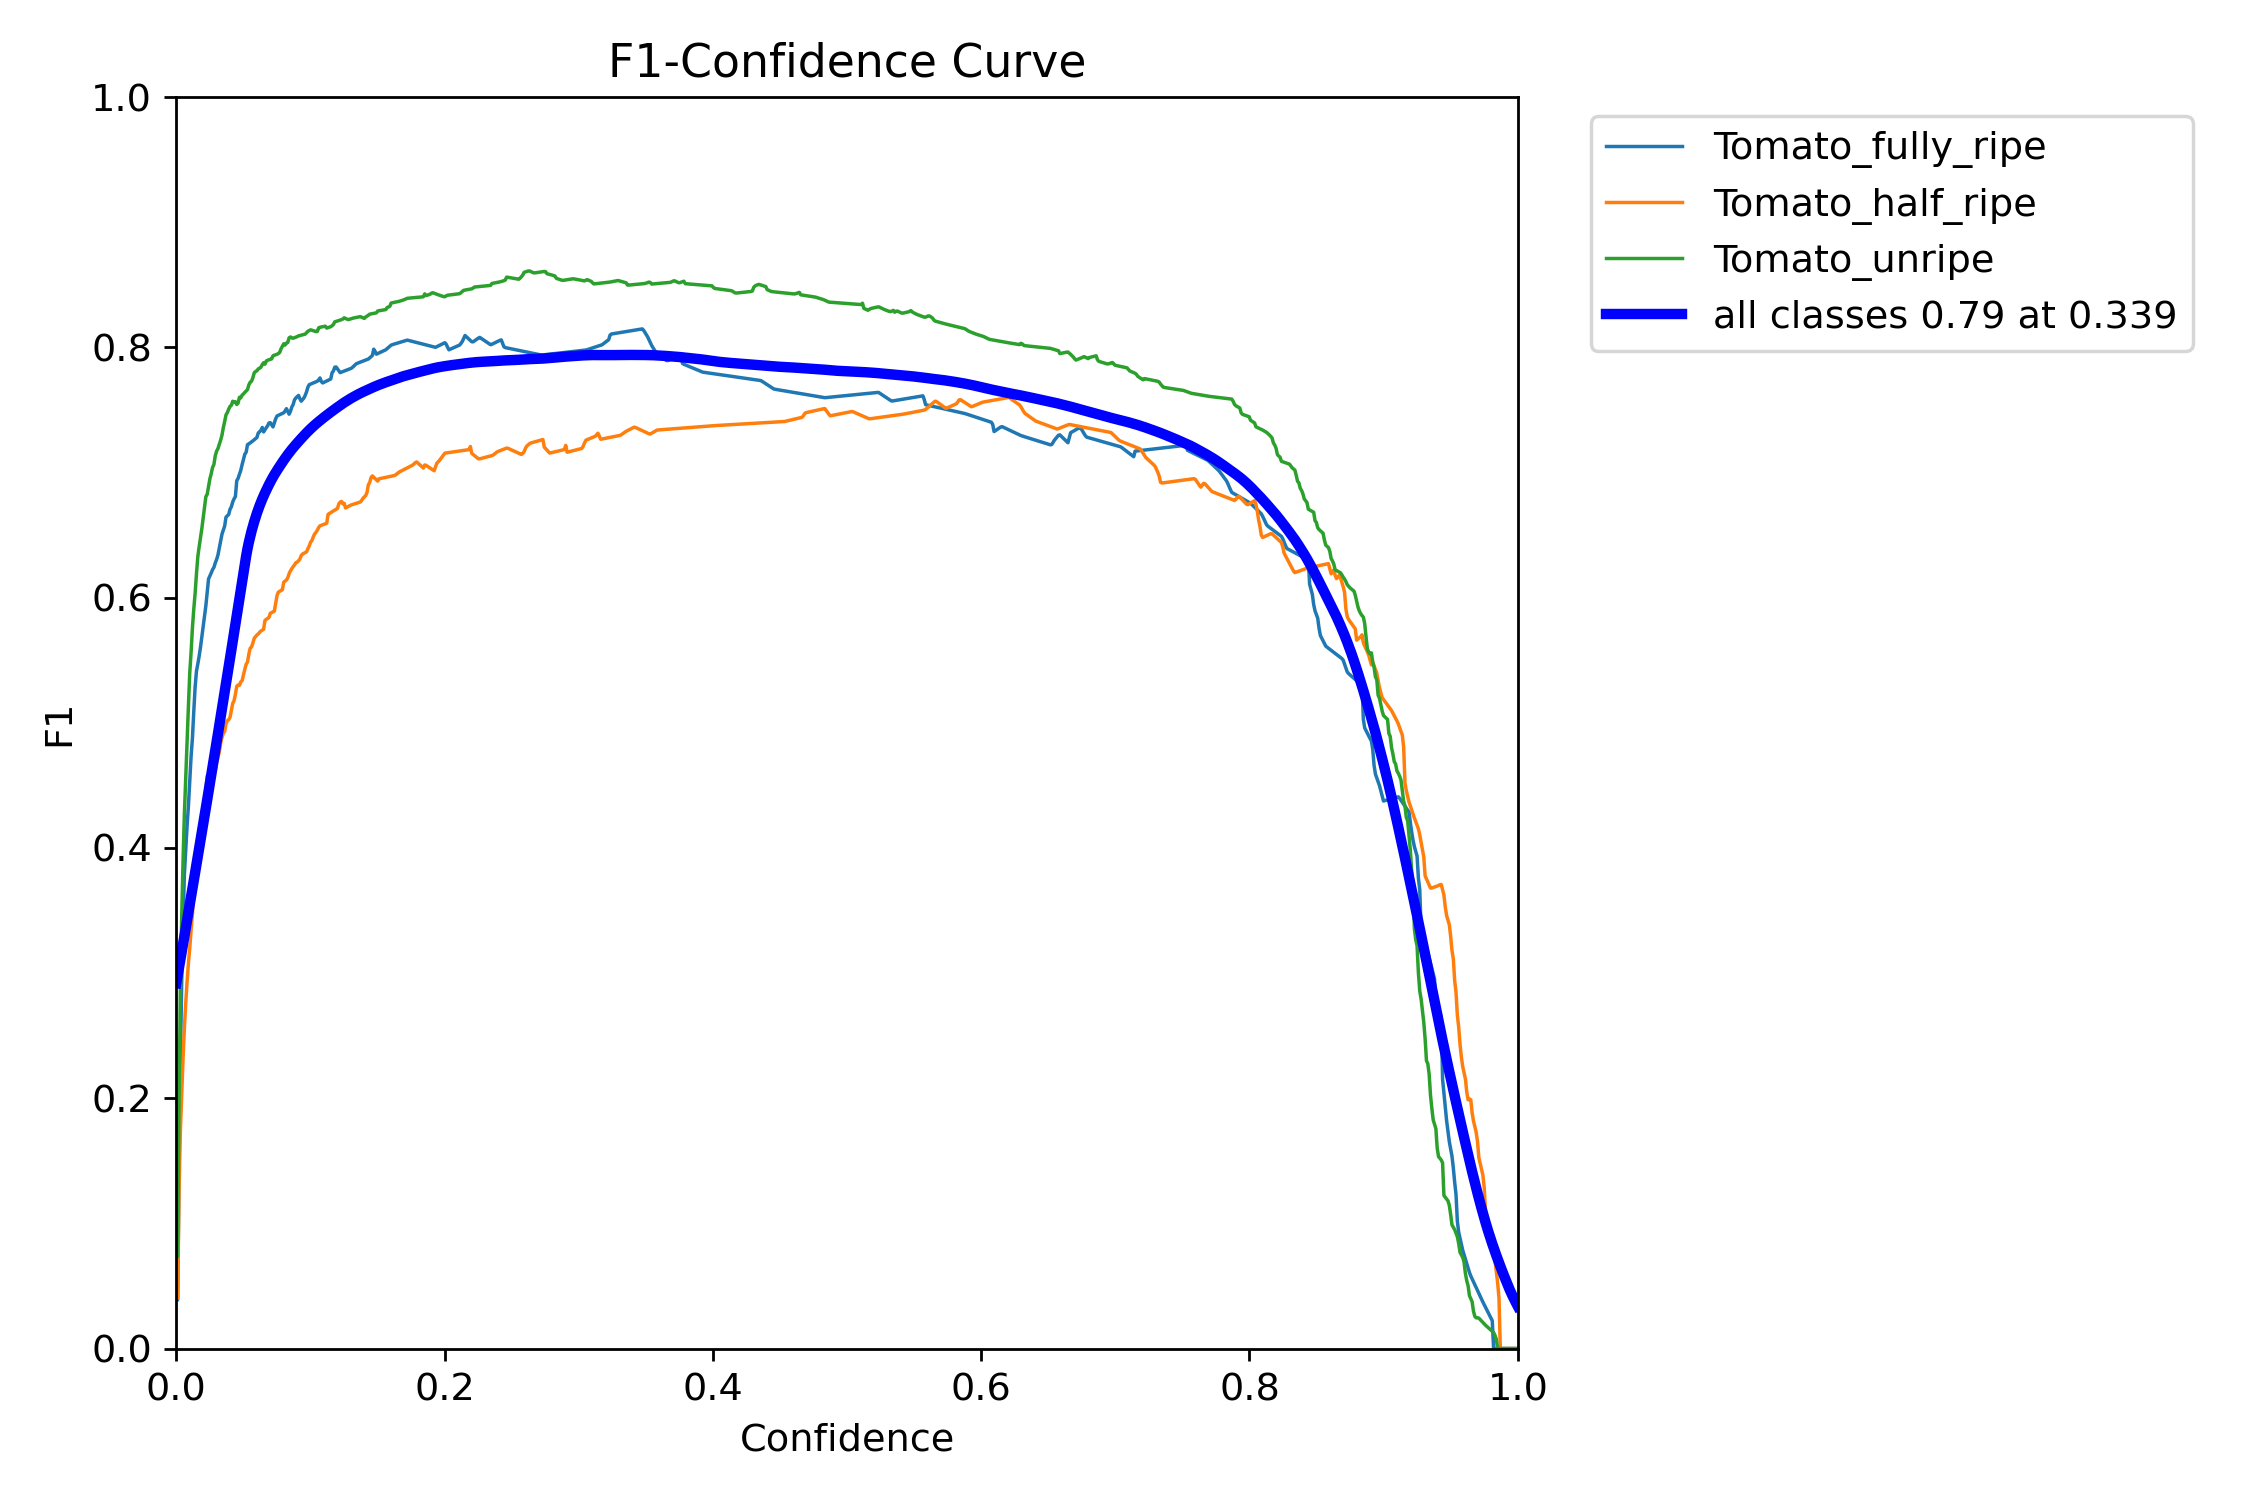

In [8]:
from IPython.display import Image as IPyImage, display
display(IPyImage('/content/runs/detect/exp_scale/BoxF1_curve.png', width=520))